# NITID: 1º tutorial, usign pre-trained models

Nitid it is an object detector that simplifies the use of the RETR open source family and that you can easily use for whatever you want (without a restrictive license)

This notebook walks through the basic nitid workflow:
1. Set up the project environment
2. Download and wrap an official D-FINE checkpoint
3. Run prediction on a real image using pre trained AI models 
4. Inspect and save results


This notebook is written to run locally from the nitid repository. Comments are included for the small changes needed when running it later in Google Colab.

# Set up the project environment

**Local use**: run this notebook from the repository root after installing the project dependencies. 
In CMD copy and paste the following comnadas  
```
cd nitid 
uv add jupyter lab
uv run jupyter lab
```

**Future Colab use**: once the repository is public and the package/release flow is settled, replace the local setup cell with a clone/install cell, for example:

In [ ]:
# Colab-only example for the future
!git clone https://github.com/Vaelsys/nitid.git
%cd nitid
!pip install -e .

For now, this notebook uses the local checkout so we can test the unreleased code before it is merged.

In [12]:
import os
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if all((candidate / p).exists() for p in ["dfine", "tools", "configs"]):
            return candidate
    raise RuntimeError(
        "Could not find the nitid repository root. "
        "Run this notebook from the cloned nitid repo, or `cd` into it first."
    )

REPO_ROOT = find_repo_root(Path.cwd().resolve())
os.chdir(REPO_ROOT)

print(f"Running in Colab: {IN_COLAB}")
print(f"Repository root: {REPO_ROOT}")
print(f"Working directory: {Path.cwd()}")


Running in Colab: False
Repository root: /home/vaelsys/testNitid/nitid
Working directory: /home/vaelsys/testNitid/nitid


In [13]:
from nitid import NITID
print("Imported DITID successfully")

Imported DITID successfully


# Download and wrap an official D-FINE checkpoint
Nitid needs a wrapped checkpoint. A wrapped checkpoint stores the model weights, D-FINE config, and class names together in one .pth file.

The command below downloads the official D-FINE-S COCO checkpoint and converts it into:

models/nitid1s_wrapped.pth
You can replace dfine_s with dfine_m, dfine_l, or dfine_x.

In [14]:
from dfine.utils.downloads import download_model

models_dir = REPO_ROOT / "models"
models_dir.mkdir(exist_ok=True)

checkpoint = download_model("dfine_s", output=models_dir)
print(f"Checkpoint ready: {checkpoint}")
print(f"Size: {checkpoint.stat().st_size / 1e6:.1f} MB")

/home/vaelsys/testNitid/nitid/models/dfine_s_obj2coco_wrapped.pth already exists. Use force=true to overwrite.
Checkpoint ready: /home/vaelsys/testNitid/nitid/models/dfine_s_obj2coco_wrapped.pth
Size: 41.8 MB


After downloading the official D-FINE COCO Checkpoint template, you need to change its name to use it with your NITID. The following code performs this name change.

The name change does not affect the template; it simply prevents conflicts between the two. This measure is temporary.

In [30]:
import shutil
ckpt_name = str(checkpoint)
if "dfine_s" in ckpt_name:
    nitid_name = "nitid1s"
elif "dfine_m" in ckpt_name:
    nitid_name = "nitid1m"
elif "dfine_l" in ckpt_name:
    nitid_name = "nitid1l"
elif "dfine_x" in ckpt_name:
    nitid_name = "nitid1x"
else:
    raise ValueError(f"Checkpoint no reconocido: {ckpt_name}")

nitid_path = Path(nitid_name) 

if not nitid_path.exists():
    shutil.copy2(checkpoint, nitid_path)

print(f"Checkpoint original: {checkpoint}")
print(f"Alias para NITID:    {nitid_path}")

Checkpoint original: /home/vaelsys/testNitid/nitid/models/dfine_s_obj2coco_wrapped.pth
Alias para NITID:    nitid1s


# Run prediction on a real image using pre trained AI models
For running a prediction on a real image, we follow this steps:
1) Download a test image
2) Run prediction with Python

In [31]:
# The image is downloaded at runtime so the repository does not need to store example image files.

from urllib.request import urlretrieve

outputs_dir = REPO_ROOT / "outputs"
outputs_dir.mkdir(exist_ok=True)

image_url = "https://ultralytics.com/images/bus.jpg"
image_path = outputs_dir / "bus.jpg"

if not image_path.exists():
    print(f"Downloading {image_url}")
    urlretrieve(image_url, image_path)

print(f"Image ready: {image_path}")

Image ready: /home/vaelsys/testNitid/nitid/outputs/bus.jpg


In [36]:
# This is the main user-facing workflow.
model = NITID(str(nitid_path), device="cpu", verbose=False)
results = model.predict(str(image_path), conf=0.5, verbose=False)

result = results[0]
detections = result.to_json()

print(result)
print("Detections:", len(result))
print(detections)

dfine_s_obj2coco_wrapped.pth already exists. Use force=true to overwrite.
Results(path='/home/vaelsys/testNitid/nitid/outputs/bus.jpg', detections=5, masks=0, keypoints=0, obb=0)
Detections: 5
[{'confidence': 0.9039, 'class': 0, 'name': 'person', 'box': {'x1': 50.0741081237793, 'y1': 396.7444152832031, 'x2': 244.94932556152344, 'y2': 904.1151733398438}}, {'confidence': 0.8869, 'class': 0, 'name': 'person', 'box': {'x1': 222.96536254882812, 'y1': 405.1080322265625, 'x2': 344.267578125, 'y2': 860.7843627929688}}, {'confidence': 0.8468, 'class': 0, 'name': 'person', 'box': {'x1': 668.8526611328125, 'y1': 382.3203430175781, 'x2': 809.7160034179688, 'y2': 880.129150390625}}, {'confidence': 0.8202, 'class': 5, 'name': 'bus', 'box': {'x1': 5.641345500946045, 'y1': 226.54551696777344, 'x2': 803.3975219726562, 'y2': 802.8450927734375}}, {'confidence': 0.5984, 'class': 0, 'name': 'person', 'box': {'x1': 0.10831564664840698, 'y1': 550.0048828125, 'x2': 74.71338653564453, 'y2': 873.3046875}}]


Saved annotated image to: /home/vaelsys/testNitid/nitid/outputs/bus_result.jpg


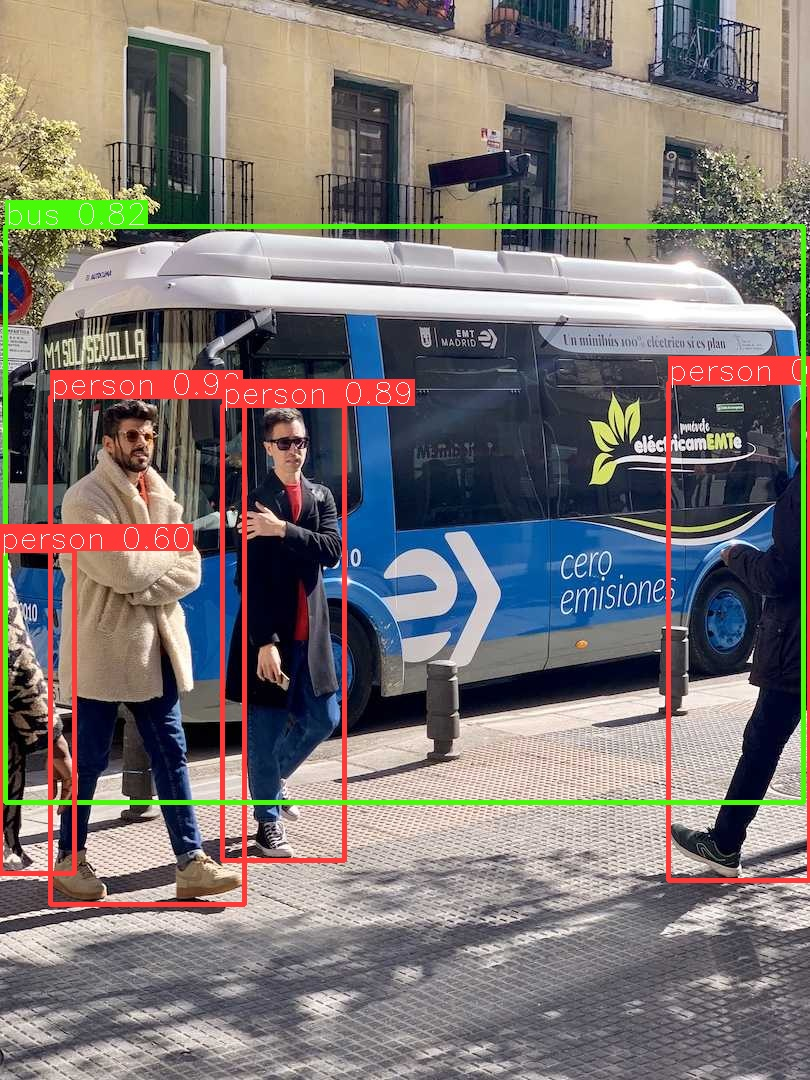

In [37]:
try:
    from IPython.display import Image, display
except ImportError:
    Image = None
    display = None

annotated_path = outputs_dir / "bus_result.jpg"

# results.save() writes an annotated image with boxes and labels.
result.save(str(annotated_path))
print(f"Saved annotated image to: {annotated_path}")

if Image is not None and display is not None:
    display(Image(filename=str(annotated_path)))
else:
    print("Install IPython or open the saved file to view the annotated image.")

# Other forms
In the following code snippets, we will present a way to perform an inference on an image using a different execution method.

In this case, we don't use an official D-FINE-S COCO checkpoint model wrapped in the code. Instead, we directly use the `ded NITID` command with the `nitid1s` model.

The `nitid1s` model can be replaced by `nitid1n`, `nitid1m`, `nitid1l`, or `nitid1x`.

Besides performing detection tasks, it can also perform segmentation, semantics, pose detection, and oriented bounding boxes.

dfine_s_obj2coco_wrapped.pth already exists. Use force=true to overwrite.
[D-FINE] Loaded 'dfine_s_obj2coco_wrapped.pth' — 10.3M params on cpu
Saved annotated image to: outputs_2/bus_det_annotated.jpg


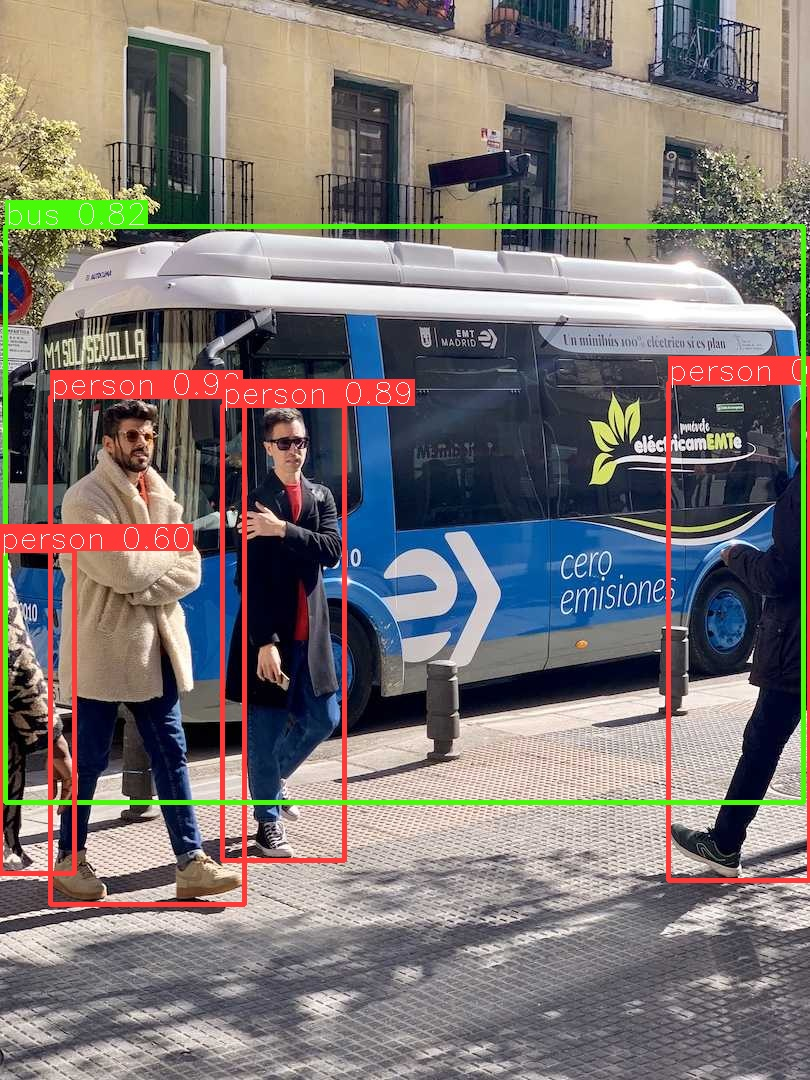

In [45]:
# workflow for detection 
outputs_dir = Path("outputs_2")
outputs_dir.mkdir(exist_ok=True)

model = NITID("nitid1s", task="detect")
result = model.predict(str(image_path), conf=0.5)
result=result[0]

annotated_path = outputs_dir / "bus_det_annotated.jpg"
result.save(str(annotated_path))
print(f"Saved annotated image to: {annotated_path}")

if Image is not None and display is not None:
    display(Image(filename=str(annotated_path)))

dfine_seg_s_coco_wrapped.pth already exists. Use force=true to overwrite.
[D-FINE] Loaded 'dfine_seg_s_coco_wrapped.pth' — 11.9M params on cpu
torch.Size([5, 1080, 810])
Saved annotated image to: outputs_2/bus_seg_annotated.jpg


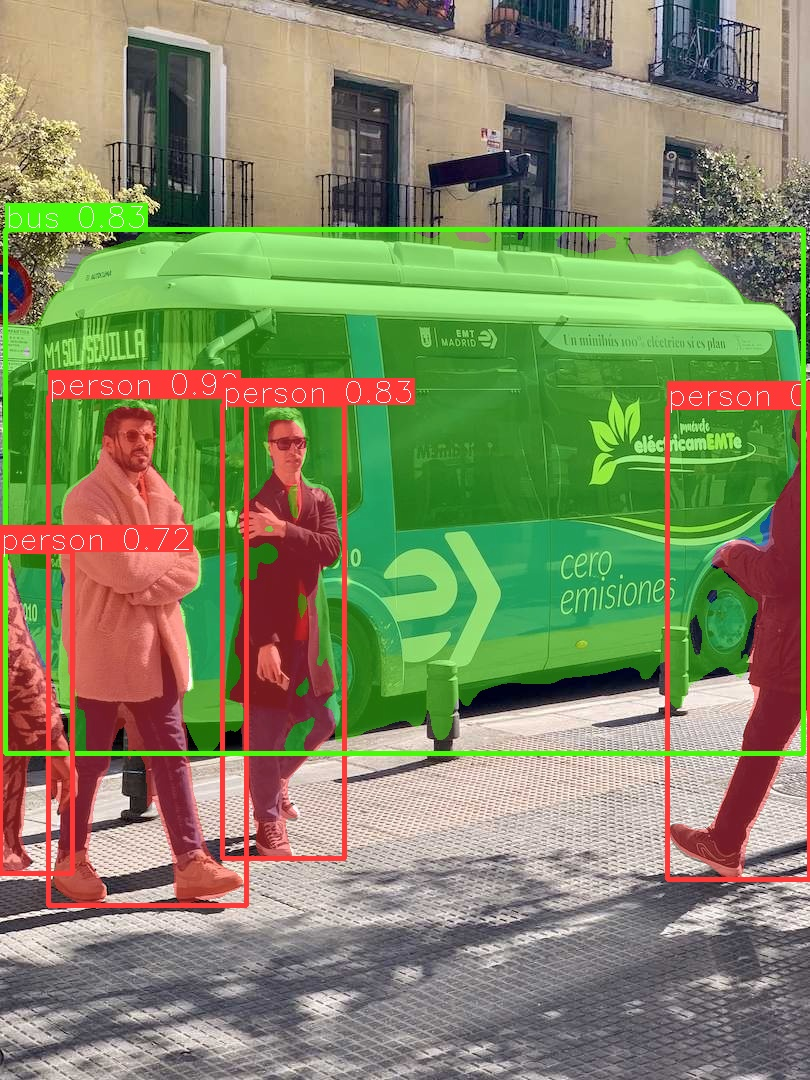

In [48]:
# workflow for segmentation 
model = NITID("nitid1s", task="segment")
result = model.predict(str(image_path), conf=0.5)[0]
print(result.masks.data.shape)  # [N, H, W]

annotated_path = outputs_dir / "bus_seg_annotated.jpg"
result.save(str(annotated_path))
print(f"Saved annotated image to: {annotated_path}")

if Image is not None and display is not None:
    display(Image(filename=str(annotated_path)))

In [56]:
# workflow for semantic
model = NITID("nitid1s", task="semantic")
result = model.predict(str(image_path), return_probs=True)[0]
print(result.semantic.mask.shape)  # [H, W]

annotated_path = outputs_dir / "bus_semantic_annotated.jpg"
result.save_semantic(str(annotated_path))
print(f"Saved annotated image to: {annotated_path}")

dfine_semantic_s_coco_init_wrapped.pth already exists. Use force=true to overwrite.
[D-FINE] Loaded 'dfine_semantic_s_coco_init_wrapped.pth' — 8.0M params on cpu
torch.Size([1080, 810])
Saved annotated image to: outputs_2/bus_semantic_annotated.jpg


detrpose_s_coco_wrapped.pth already exists. Use force=true to overwrite.
[D-FINE] Loaded 'detrpose_s_coco_wrapped.pth' — 11.6M params on cpu
Saved annotated image to: outputs_2/bus_pose_annotated.jpg


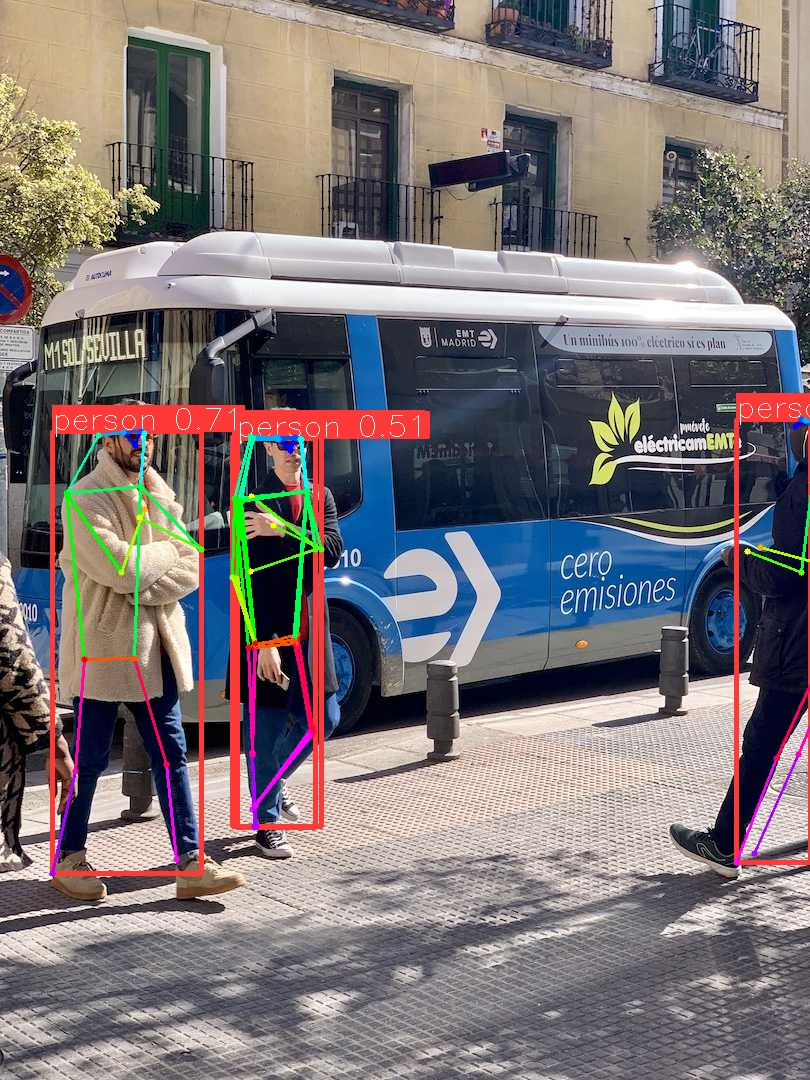

In [55]:
# workflow for pose
pose = NITID("nitid1s", task="pose")
result = pose.predict(str(image_path), conf=0.5)[0]

keypoints = result.keypoints.xy  # [N, 17, 2] in pixel coordinates
annotated_path = outputs_dir / "bus_pose_annotated.jpg"
result.save(str(annotated_path))
print(f"Saved annotated image to: {annotated_path}")

if Image is not None and display is not None:
    display(Image(filename=str(annotated_path)))


In [65]:
# workflow for oriented bounding boxes
obb = NITID("nitid1s", task="obb")
result = obb.predict(str(image_path), conf=0.25)[0]

rotated = result.obb.xywhr       # [N, 5]: cx, cy, w, h, angle
corners = result.obb.xyxyxyxy    # [N, 8]: four polygon corners
result.save("obb.jpg")

ValueError: Checkpoint task is 'detect', but task='obb' was requested